# Compare Runs

Load every `summary.json` under `results/` and visualize entity-level F1, per-class F1, precision/recall, and training time across runs.

In [39]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR

PosixPath('/Users/dayanbattulga/Desktop/personal-code/misc/dunedain_ner/results')

In [40]:
summary_paths = sorted(RESULTS_DIR.glob('*/summary.json'))
print(f'Found {len(summary_paths)} summary.json files:')
for p in summary_paths:
    print(' -', p.relative_to(REPO_ROOT))

Found 15 summary.json files:
 - results/deberta_efficient_seed5768/summary.json
 - results/deberta_efficient_seed5768_seed5768/summary.json
 - results/deberta_efficient_seed78516/summary.json
 - results/deberta_efficient_seed78516_seed78516/summary.json
 - results/deberta_efficient_seed88/summary.json
 - results/deberta_efficient_seed88_seed88/summary.json
 - results/efficient_training_seed5768/summary.json
 - results/efficient_training_seed78516/summary.json
 - results/efficient_training_seed88/summary.json
 - results/phase_b_teacher_seed5768/summary.json
 - results/phase_b_teacher_seed78516/summary.json
 - results/phase_b_teacher_seed88/summary.json
 - results/teacher_crf_seed5768/summary.json
 - results/teacher_crf_seed78516/summary.json
 - results/teacher_crf_seed88/summary.json


In [41]:
def load_summary(path: Path) -> dict:
    with open(path) as f:
        data = json.load(f)
    cfg = data.get('config', {})
    val = data.get('val_metrics', {}) or {}
    test = data.get('test_metrics', {}) or {}
    val_per = val.get('entity_per_class', {})
    test_per = test.get('entity_per_class', {})
    return {
        'run_id': data.get('run_id', path.parent.name),
        'model': cfg.get('model_name'),
        'seed': cfg.get('resolved_seed', (cfg.get('seeds') or [None])[0]),
        'use_crf': cfg.get('use_crf', False),
        'use_distillation': cfg.get('use_distillation', False),
        'num_epochs': cfg.get('num_epochs'),
        'lr': cfg.get('learning_rate'),
        'param_count': data.get('param_count'),
        'train_time_min': data.get('train_time_min'),
        'best_val_entity_f1': data.get('best_validation_entity_f1'),
        'val_token_f1': val.get('token_weighted_f1'),
        'val_entity_f1': val.get('entity_overall_f1'),
        'val_entity_precision': val.get('entity_overall_precision'),
        'val_entity_recall': val.get('entity_overall_recall'),
        'val_per_f1': val_per.get('PER'),
        'val_loc_f1': val_per.get('LOC'),
        'val_org_f1': val_per.get('ORG'),
        'test_token_f1': test.get('token_weighted_f1'),
        'test_entity_f1': test.get('entity_overall_f1'),
        'test_entity_precision': test.get('entity_overall_precision'),
        'test_entity_recall': test.get('entity_overall_recall'),
        'test_per_f1': test_per.get('PER'),
        'test_loc_f1': test_per.get('LOC'),
        'test_org_f1': test_per.get('ORG'),
    }

rows = [load_summary(p) for p in summary_paths]
df = pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)
df

,run_id,model,seed,use_crf,use_distillation,num_epochs,lr,param_count,train_time_min,best_val_entity_f1,...,val_per_f1,val_loc_f1,val_org_f1,test_token_f1,test_entity_f1,test_entity_precision,test_entity_recall,test_per_f1,test_loc_f1,test_org_f1
0,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768,False,False,5,0.00005,434019335,8.169544,0.917355,...,0.992754,0.923077,0.875000,0.983737,0.839413,0.803371,0.878841,0.940351,0.839937,0.790541
1,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768,False,False,5,0.00005,434019335,8.169544,0.917355,...,0.992754,0.923077,0.875000,0.983737,0.839413,0.803371,0.878841,0.940351,0.839937,0.790541
2,deberta_efficient_seed78516_seed78516,microsoft/deberta-v3-large,78516,False,False,5,0.00005,434019335,8.188015,0.908036,...,0.974910,0.922280,0.863469,0.983400,0.836855,0.806846,0.869183,0.938918,0.830918,0.790102
3,deberta_efficient_seed78516_seed78516,microsoft/deberta-v3-large,78516,False,False,5,0.00005,434019335,8.188015,0.908036,...,0.974910,0.922280,0.863469,0.983400,0.836855,0.806846,0.869183,0.938918,0.830918,0.790102
4,deberta_efficient_seed88_seed88,microsoft/deberta-v3-large,88,False,False,5,0.00005,434019335,8.209122,0.914005,...,0.982079,0.928934,0.868613,0.983066,0.835997,0.802260,0.872695,0.938704,0.841270,0.783347
5,deberta_efficient_seed88_seed88,microsoft/deberta-v3-large,88,False,False,5,0.00005,434019335,8.209122,0.914005,...,0.982079,0.928934,0.868613,0.983066,0.835997,0.802260,0.872695,0.938704,0.841270,0.783347
6,efficient_training_seed5768,roberta-large,5768,True,False,5,0.00003,355366982,7.308268,0.919768,...,0.971014,0.948718,0.872928,0.985414,0.842414,0.805934,0.882353,0.935201,0.839937,0.798986
7,efficient_training_seed78516,roberta-large,78516,True,False,5,0.00003,355366982,7.306040,0.916460,...,0.967742,0.953846,0.862963,0.986074,0.855335,0.823052,0.890255,0.956522,0.846276,0.810300
8,efficient_training_seed88,roberta-large,88,True,False,5,0.00003,355366982,7.315161,0.925620,...,0.981949,0.956298,0.875000,0.985703,0.846672,0.813765,0.882353,0.945899,0.848485,0.797274
9,phase_b_teacher_seed5768,roberta-large,5768,False,False,30,0.00001,354317319,47.715483,0.917842,...,0.967509,0.930591,0.883117,0.985226,0.850991,0.835165,0.867428,0.956217,0.844371,0.802092


## Overall entity F1 (validation vs test)

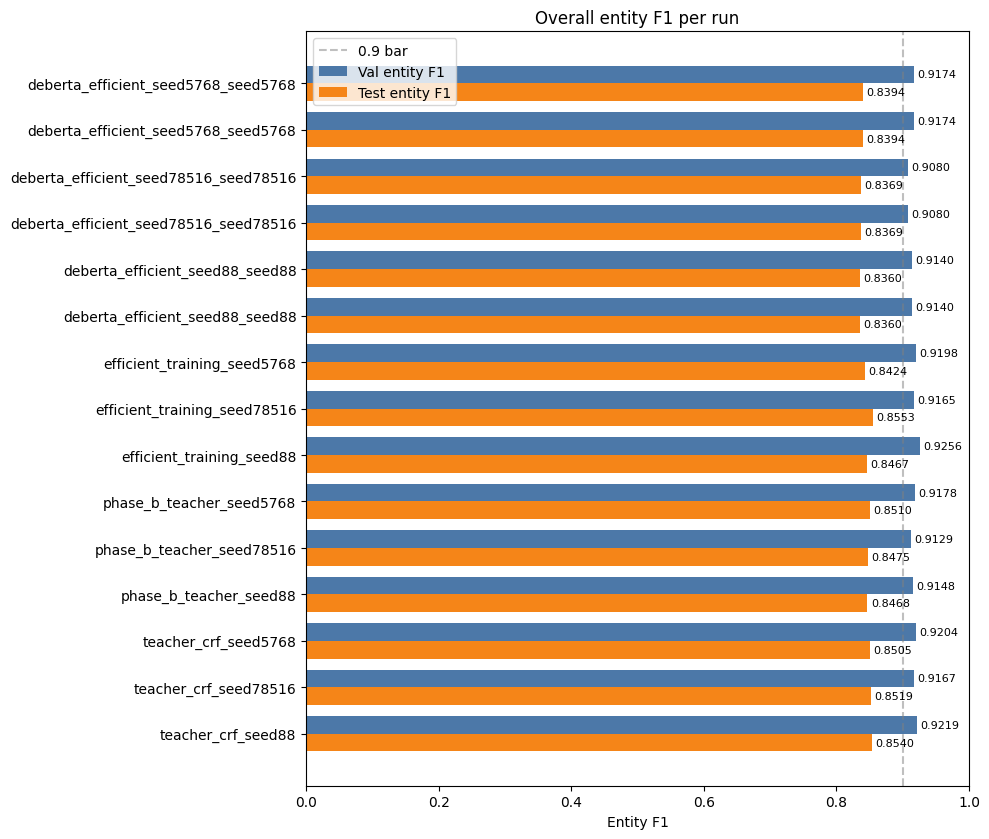

In [42]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.38
ax.barh(y - h/2, df['val_entity_f1'].fillna(0), h, label='Val entity F1', color='#4C78A8')
ax.barh(y + h/2, df['test_entity_f1'].fillna(0), h, label='Test entity F1', color='#F58518')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Entity F1')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5, label='0.9 bar')
ax.legend(loc='upper left')
ax.invert_yaxis()
ax.set_title('Overall entity F1 per run')
for i, (v, t) in enumerate(zip(df['val_entity_f1'], df['test_entity_f1'])):
    if pd.notna(v):
        ax.text(v + 0.005, i - h/2, f'{v:.4f}', va='center', fontsize=8)
    if pd.notna(t):
        ax.text(t + 0.005, i + h/2, f'{t:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Per-class entity F1 on test set

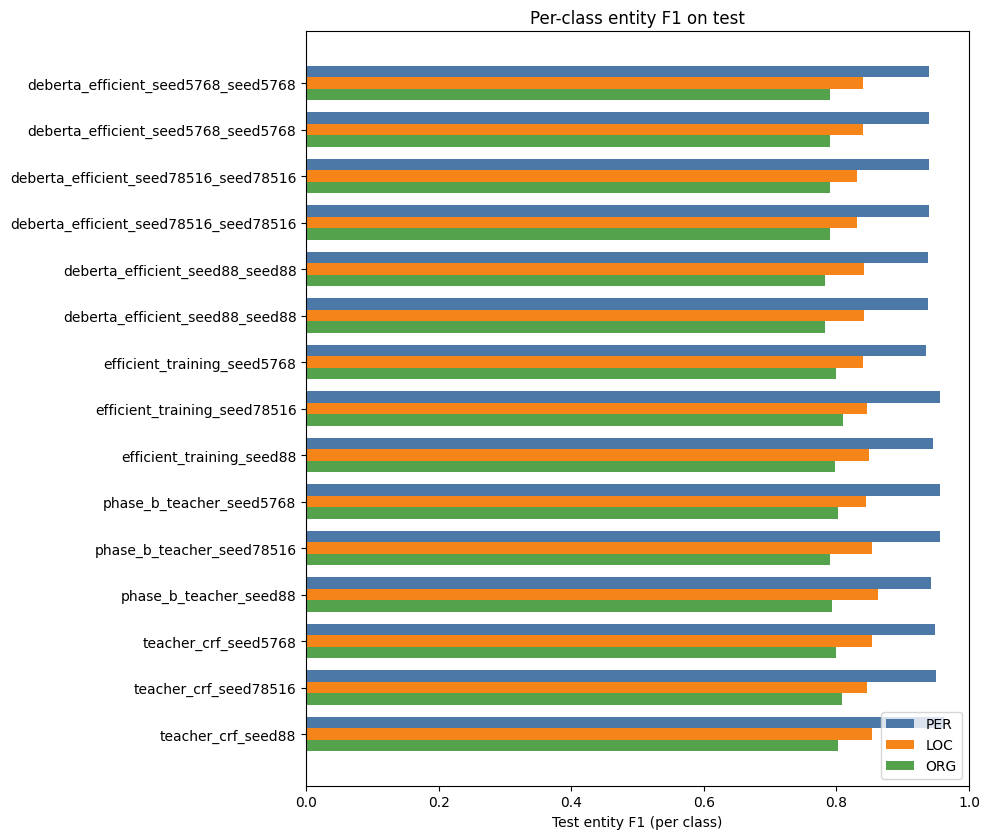

In [43]:
classes = ['PER', 'LOC', 'ORG']
cols = ['test_per_f1', 'test_loc_f1', 'test_org_f1']
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
colors = ['#4C78A8', '#F58518', '#54A24B']
for i, (c, col, color) in enumerate(zip(classes, cols, colors)):
    offset = (i - 1) * h
    ax.barh(y + offset, df[col].fillna(0), h, label=c, color=color)
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Test entity F1 (per class)')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Per-class entity F1 on test')
plt.tight_layout()
plt.show()

## Precision / Recall / F1 on test set

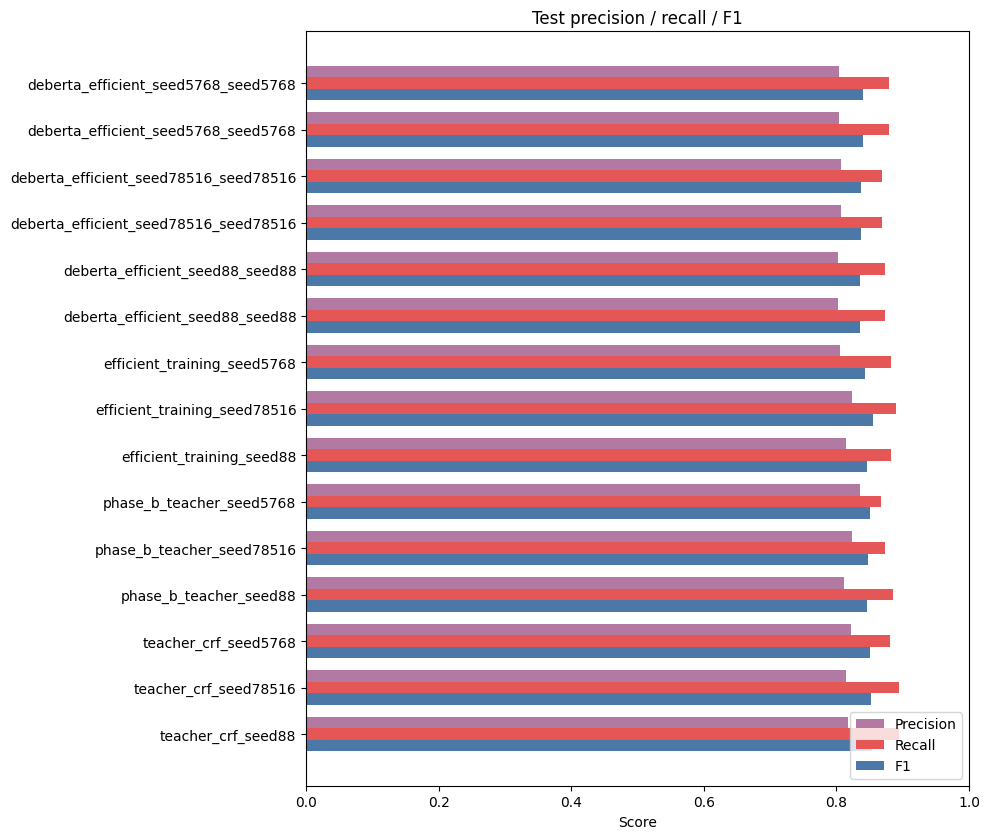

In [44]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
ax.barh(y - h, df['test_entity_precision'].fillna(0), h, label='Precision', color='#B279A2')
ax.barh(y,      df['test_entity_recall'].fillna(0),    h, label='Recall',    color='#E45756')
ax.barh(y + h,  df['test_entity_f1'].fillna(0),        h, label='F1',        color='#4C78A8')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Score')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Test precision / recall / F1')
plt.tight_layout()
plt.show()

## Train time vs test entity F1

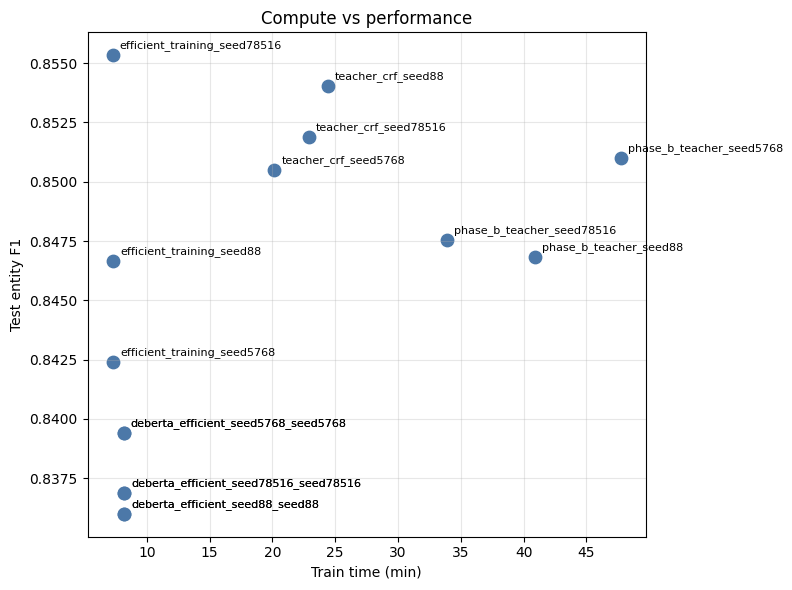

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
sub = df.dropna(subset=['train_time_min', 'test_entity_f1'])
ax.scatter(sub['train_time_min'], sub['test_entity_f1'], s=80, color='#4C78A8')
for _, row in sub.iterrows():
    ax.annotate(row['run_id'], (row['train_time_min'], row['test_entity_f1']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Train time (min)')
ax.set_ylabel('Test entity F1')
ax.set_title('Compute vs performance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Seed aggregation (mean ± std by model / variant)

In [46]:
def variant(row):
    tag = row['model'] or 'unknown'
    if row['use_crf']:
        tag += '+crf'
    if row['use_distillation']:
        tag += '+distill'
    return tag

df['variant'] = df.apply(variant, axis=1)
# strip seed suffix so multi-seed runs collapse
df['run_group'] = df['run_id'].str.replace(r'_seed\d+$', '', regex=True)

agg_cols = ['test_entity_f1', 'test_per_f1', 'test_loc_f1', 'test_org_f1', 'test_token_f1']
agg = df.groupby('run_group')[agg_cols].agg(['mean', 'std', 'count'])
agg

test_entity_f1                 test_per_f1  \
                                      mean       std count        mean   
run_group                                                                
deberta_efficient_seed5768        0.839413  0.000000     2    0.940351   
deberta_efficient_seed78516       0.836855  0.000000     2    0.938918   
deberta_efficient_seed88          0.835997  0.000000     2    0.938704   
efficient_training                0.848141  0.006585     3    0.945874   
phase_b_teacher                   0.848451  0.002227     3    0.951780   
teacher_crf                       0.852132  0.001783     3    0.953112   

                                            test_loc_f1                  \
                                  std count        mean       std count   
run_group                                                                 
deberta_efficient_seed5768   0.000000     2    0.839937  0.000000     2   
deberta_efficient_seed78516  0.000000     2    0.830918  0.000000     2   
deberta_efficient_seed88     0.000000     2    0.841270  0.000000     2   
efficient_training           0.010660     3    0.844899  0.004437     3   
phase_b_teacher              0.007552     3    0.853818  0.009169     3   
teacher_crf                  0.007450     3    0.850969  0.004845     3   

                            test_org_f1                 test_token_f1  \
                                   mean       std count          mean   
run_group                                                               
deberta_efficient_seed5768     0.790541  0.000000     2      0.983737   
deberta_efficient_seed78516    0.790102  0.000000     2      0.983400   
deberta_efficient_seed88       0.783347  0.000000     2      0.983066   
efficient_training             0.802187  0.007078     3      0.985730   
phase_b_teacher                0.795355  0.006075     3      0.985160   
teacher_crf                    0.803161  0.004182     3      0.985337   

                                             
                                  std count  
run_group                                    
deberta_efficient_seed5768   0.000000     2  
deberta_efficient_seed78516  0.000000     2  
deberta_efficient_seed88     0.000000     2  
efficient_training           0.000331     3  
phase_b_teacher              0.000136     3  
teacher_crf                  0.000167     3

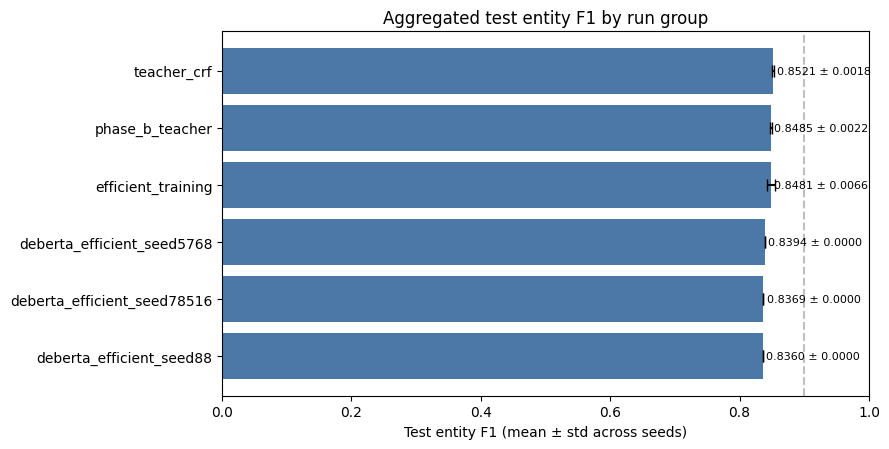

In [47]:
means = df.groupby('run_group')['test_entity_f1'].mean()
stds = df.groupby('run_group')['test_entity_f1'].std().fillna(0)
order = means.sort_values().index
fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(order) + 1)))
y = np.arange(len(order))
ax.barh(y, means.loc[order], xerr=stds.loc[order], color='#4C78A8', capsize=4)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel('Test entity F1 (mean ± std across seeds)')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5)
ax.set_title('Aggregated test entity F1 by run group')
for i, g in enumerate(order):
    ax.text(means.loc[g] + 0.005, i, f'{means.loc[g]:.4f} ± {stds.loc[g]:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Raw comparison table

In [48]:
display_cols = ['run_id', 'model', 'seed', 'num_epochs', 'param_count', 'train_time_min',
                'best_val_entity_f1', 'val_entity_f1', 'test_entity_f1',
                'test_per_f1', 'test_loc_f1', 'test_org_f1']
df[display_cols].style.format({
    'best_val_entity_f1': '{:.4f}',
    'val_entity_f1': '{:.4f}',
    'test_entity_f1': '{:.4f}',
    'test_per_f1': '{:.4f}',
    'test_loc_f1': '{:.4f}',
    'test_org_f1': '{:.4f}',
    'train_time_min': '{:.2f}',
    'param_count': '{:,.0f}',
}, na_rep='-')

,run_id,model,seed,num_epochs,param_count,train_time_min,best_val_entity_f1,val_entity_f1,test_entity_f1,test_per_f1,test_loc_f1,test_org_f1
0,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768,5,"434,019,335",8.17,0.9174,0.9174,0.8394,0.9404,0.8399,0.7905
1,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768,5,"434,019,335",8.17,0.9174,0.9174,0.8394,0.9404,0.8399,0.7905
2,deberta_efficient_seed78516_seed78516,microsoft/deberta-v3-large,78516,5,"434,019,335",8.19,0.9080,0.9080,0.8369,0.9389,0.8309,0.7901
3,deberta_efficient_seed78516_seed78516,microsoft/deberta-v3-large,78516,5,"434,019,335",8.19,0.9080,0.9080,0.8369,0.9389,0.8309,0.7901
4,deberta_efficient_seed88_seed88,microsoft/deberta-v3-large,88,5,"434,019,335",8.21,0.9140,0.9140,0.8360,0.9387,0.8413,0.7833
5,deberta_efficient_seed88_seed88,microsoft/deberta-v3-large,88,5,"434,019,335",8.21,0.9140,0.9140,0.8360,0.9387,0.8413,0.7833
6,efficient_training_seed5768,roberta-large,5768,5,"355,366,982",7.31,0.9198,0.9198,0.8424,0.9352,0.8399,0.7990
7,efficient_training_seed78516,roberta-large,78516,5,"355,366,982",7.31,0.9165,0.9165,0.8553,0.9565,0.8463,0.8103
8,efficient_training_seed88,roberta-large,88,5,"355,366,982",7.32,0.9256,0.9256,0.8467,0.9459,0.8485,0.7973
9,phase_b_teacher_seed5768,roberta-large,5768,30,"354,317,319",47.72,0.9178,0.9178,0.8510,0.9562,0.8444,0.8021
